In [1]:
import pandas as pd

In [2]:
data1 = pd.read_csv("data_divided/training_full.csv")
data2 = pd.read_csv("data_divided/validation_full.csv")

data = pd.concat([data1, data2])



In [3]:
data.info()

<class 'pandas.DataFrame'>
Index: 16724 entries, 0 to 4180
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price_numeric   16724 non-null  float64
 1   Height          16724 non-null  float64
 2   Width           16724 non-null  float64
 3   Uniqueness      16724 non-null  str    
 4   gender_guessed  16724 non-null  str    
 5   gallery         16724 non-null  str    
 6   painting        16724 non-null  str    
 7   is_signed       16724 non-null  str    
 8   age             16724 non-null  float64
 9   years_selling   16724 non-null  float64
 10  location        16724 non-null  str    
 11  image_path      16724 non-null  str    
dtypes: float64(5), str(7)
memory usage: 2.7 MB


In [4]:
df_clusters = data.drop(columns = 'image_path')

In [5]:
cat_cols = df_clusters.select_dtypes(include = 'object').columns.to_list()
num_cols = df_clusters.select_dtypes(include = 'number').columns.to_list()

print(cat_cols)
print(num_cols)

['Uniqueness', 'gender_guessed', 'gallery', 'painting', 'is_signed', 'location']
['price_numeric', 'Height', 'Width', 'age', 'years_selling']


C:\Users\yana1\AppData\Local\Temp\ipykernel_9968\3711378942.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clusters.select_dtypes(include = 'object').columns.to_list()


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_clusters[num_cols] = scaler.fit_transform(df_clusters[num_cols])

In [7]:
X = df_clusters.to_numpy()

In [8]:
cat_idx = [df_clusters.columns.get_loc(col) for col in cat_cols]

print(cat_idx)

[3, 4, 5, 6, 7, 10]


In [9]:
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt

cost = []

K = range(2, 11)

for k in K:
    
    kproto = KPrototypes(
        n_clusters=k,
        init='Cao',
        verbose=0,
        random_state=42
    )

    clusters = kproto.fit_predict(X, categorical=cat_idx)

    cost.append(kproto.cost_)


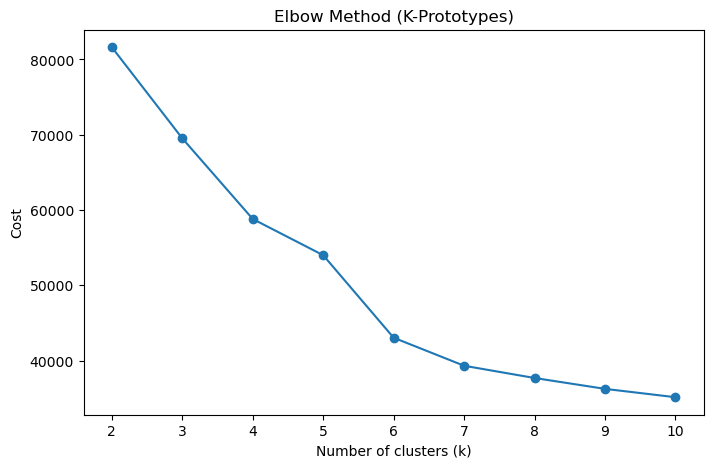

In [10]:

plt.figure(figsize=(8,5))
plt.plot(K, cost, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Cost")
plt.title("Elbow Method (K-Prototypes)")
plt.show()

In [11]:
kproto = KPrototypes(
    n_clusters=5,
    init='Cao',
    verbose=1,
    random_state=42
)

clusters = kproto.fit_predict(X, categorical=cat_idx)

df_clusters["cluster"] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 6837, ncost: 57657.02890492662
Run: 1, iteration: 2/100, moves: 1424, ncost: 55082.417211124004
Run: 1, iteration: 3/100, moves: 303, ncost: 54980.00828589859
Run: 1, iteration: 4/100, moves: 80, ncost: 54976.691884533284
Run: 1, iteration: 5/100, moves: 23, ncost: 54976.45959184295
Run: 1, iteration: 6/100, moves: 7, ncost: 54976.42844739032
Run: 1, iteration: 7/100, moves: 8, ncost: 54976.40929989367
Run: 1, iteration: 8/100, moves: 0, ncost: 54976.40929989367
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 4321, ncost: 55532.6676535448
Run: 2, iteration: 2/100, moves: 1292, ncost: 54947.918254588905
Run: 2, iteration: 3/100, moves: 783, ncost: 54606.32291468444
Run: 2, iteration: 4/100, moves: 507, ncost: 54511.45009951229
Run: 2, it

In [12]:
df_clusters["cluster"] = clusters
data["cluster"] = df_clusters["cluster"]

In [13]:
data.groupby("cluster")[num_cols].mean()

,price_numeric,Height,Width,age,years_selling
cluster,,,,,
0,1345.080045,19.763173,19.297642,4.084765,2.983764
1,4998.047468,20.066851,21.084177,68.609177,5.878165
2,2250.760186,25.760045,24.490361,5.145324,9.032596
3,3001.097229,37.851869,37.721383,3.143495,3.445749
4,13346.397686,57.179848,62.585662,5.616775,6.356471


In [14]:
import numpy as np
import pandas as pd

# extract centroids
num_centroids = kproto.cluster_centroids_[0]
cat_centroids = kproto.cluster_centroids_[1]
gamma = kproto.gamma

# mixed distance function
def kproto_distance(row, num_proto, cat_proto):
    num_dist = np.sum((row[num_cols].values.astype(float) - num_proto.astype(float))**2)
    cat_dist = np.sum(row[cat_cols].values.astype(str) != cat_proto.astype(str))
    return num_dist + gamma * cat_dist

# find nearest observation to each cluster centre
nearest_rows = []

for cl in range(kproto.n_clusters):

    cluster_rows = df_clusters[df_clusters["cluster"] == cl]

    num_proto = num_centroids[cl]
    cat_proto = cat_centroids[cl]

    distances = cluster_rows.apply(
        lambda row: kproto_distance(row, num_proto, cat_proto),
        axis=1
    )

    nearest_idx = distances.idxmin()

    nearest_rows.append({
    "cluster": cl,
    "row_index": nearest_idx,
    "image_path": data["image_path"].iloc[nearest_idx]
})

nearest_images = pd.DataFrame(nearest_rows)

nearest_images

,cluster,row_index,image_path
0,0,6305,images_thesis\1216224_1_m.jpg
1,1,4904,images_thesis\1578741_1_m.jpg
2,2,1377,images_thesis\2293227_1_m.jpg
3,3,11697,images_thesis\1091637_1_m.jpg
4,4,3816,images_thesis\2196194_1_m.jpg


In [31]:
nearest_images["cluster_im"] = nearest_images["cluster"] + 1

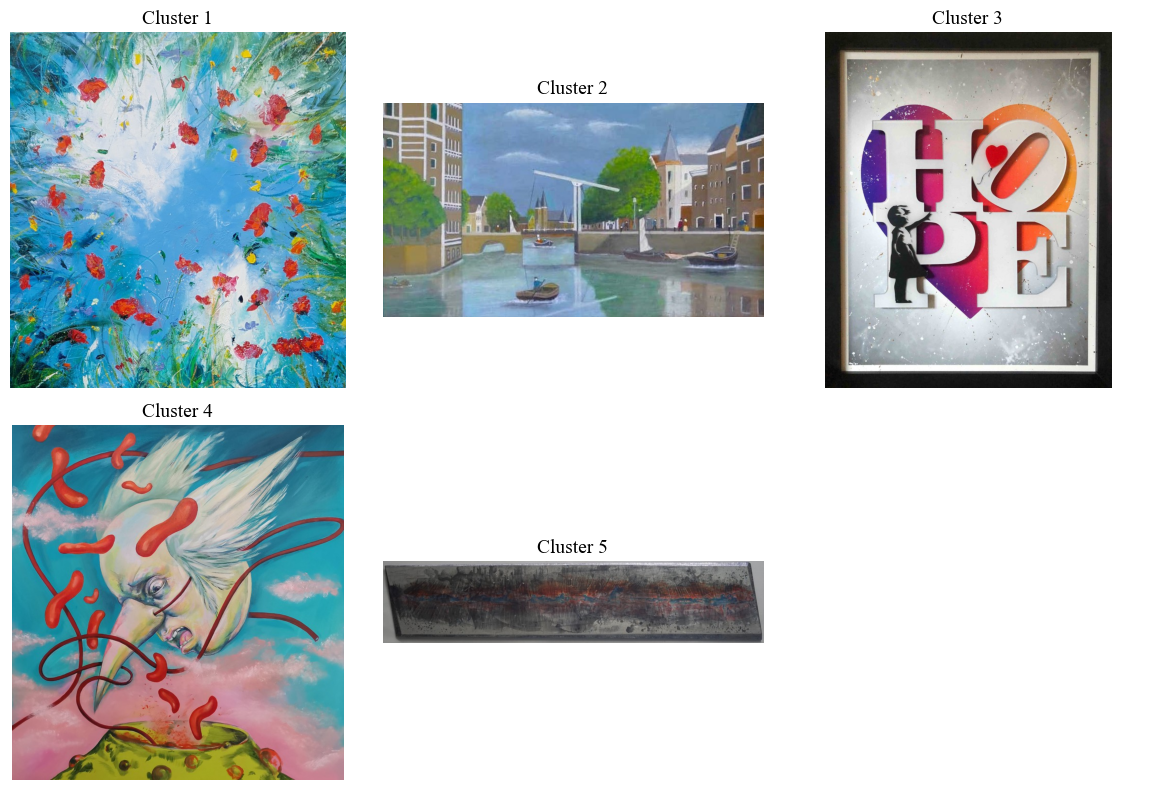

In [33]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import math

rows = 2
n = len(nearest_images)
cols = math.ceil(n / rows)

plt.rcParams['font.family'] = 'Times New Roman'

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = axes.flatten()

for i, (_, row) in enumerate(nearest_images.iterrows()):
    
    path = row["image_path"]
    cl = row["cluster_im"]
    
    if os.path.exists(path):
        img = Image.open(path)
        axes[i].imshow(img)
        axes[i].set_title(f"Cluster {cl}", fontsize=14)
        axes[i].axis("off")
    else:
        axes[i].text(0.5, 0.5, "Image not found", ha='center', va='center')
        axes[i].set_title(f"Cluster {cl}", fontsize=14)
        axes[i].axis("off")

# remove empty subplots if clusters < grid cells
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("clusters.png")

plt.show()